# CSAI 2026 — Assignment 1 — Task 1 (fMRI Mandatory)

**Allocated setup**
- SubjID: **2**
- Designated ROI: **Post-central**
- Class label (face vs X): **bottle**
- Features: `features_vt.csv` = VT(all), `features.csv` = designated ROI(all)
- Evaluation: **Leave-One-Group-Out** CV with **session/chunk** as the group


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

DATA_DIR = os.getcwd()
FEATURES_ROI_PATH = os.path.join(DATA_DIR, "features.csv")
FEATURES_VT_PATH  = os.path.join(DATA_DIR, "features_vt.csv")
LABELS_PATH       = os.path.join(DATA_DIR, "labels.txt")

print("Paths:")
print("  ROI features:", FEATURES_ROI_PATH)
print("  VT features :", FEATURES_VT_PATH)
print("  labels      :", LABELS_PATH)


Paths:
  ROI features: /home/garima/2023102069_Garima/fmri/features.csv
  VT features : /home/garima/2023102069_Garima/fmri/features_vt.csv
  labels      : /home/garima/2023102069_Garima/fmri/labels.txt


In [2]:
def load_features_whitespace_matrix(path: str) -> np.ndarray:
    """
    Loads a whitespace-separated numeric matrix.
    Returns X with shape (n_samples, n_features).
    """
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append([float(x) for x in line.split()])
    X = np.asarray(rows, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError(f"Expected a 2D matrix, got shape {X.shape}")
    return X


def load_labels_and_groups(path: str):
    """
    labels.txt format:
      labels chunks
      rest 0
      scissors 0
      ...
    Returns:
      labels: list[str]
      groups: np.ndarray[int]  (session/chunk IDs)
    """
    labels = []
    groups = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.lower().startswith("labels"):
                continue
            lab, grp = line.split()
            labels.append(lab.strip().lower())
            groups.append(int(grp))
    return labels, np.asarray(groups, dtype=int)


X_roi = load_features_whitespace_matrix(FEATURES_ROI_PATH)
X_vt_all = load_features_whitespace_matrix(FEATURES_VT_PATH)
labels, groups = load_labels_and_groups(LABELS_PATH)

print("Loaded X_roi shape   :", X_roi.shape)
print("Loaded X_vt_all shape:", X_vt_all.shape)
print("Loaded labels:", len(labels), "groups:", groups.shape, "sessions:", (groups.min(), groups.max()))

if X_roi.shape[0] != len(labels) or X_vt_all.shape[0] != len(labels):
    raise ValueError(
        f"Row mismatch: ROI rows={X_roi.shape[0]}, VT rows={X_vt_all.shape[0]}, labels={len(labels)}"
    )

print("Unique labels:", sorted(set(labels)))
print("Unique sessions:", sorted(set(groups.tolist())))


Loaded X_roi shape   : (1452, 80)
Loaded X_vt_all shape: (1452, 464)
Loaded labels: 1452 groups: (1452,) sessions: (np.int64(0), np.int64(11))
Unique labels: ['bottle', 'cat', 'chair', 'face', 'house', 'rest', 'scissors', 'scrambledpix', 'shoe']
Unique sessions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## Defining the 3 feature variants required

Per the assignment requirement:

1. **VT (all)** = all columns in `features_vt.csv`
2. **VT (random 50%)** = random half of the columns in `features_vt.csv` (seeded)
3. **Designated ROI (Post-central)** = all columns in `features.csv`

This notebook assumes both `features_vt.csv` and `features.csv` are in the same directory as `fmri.ipynb`.


In [3]:
def make_vt_half(X: np.ndarray, rng: np.random.Generator):
    """
    Randomly select half of the features/columns (without replacement).
    Returns:
      X_half: (n_samples, n_half_features)
      idx: selected column indices (sorted)
    """
    n_features = X.shape[1]
    n_half = n_features // 2  # floor
    idx = rng.choice(n_features, size=n_half, replace=False)
    idx = np.sort(idx)
    return X[:, idx], idx


# Variant 1: VT(all)
# X_vt_all already loaded from features_vt.csv

# Variant 2: VT(50%)
X_vt_50, vt50_cols = make_vt_half(X_vt_all, rng)

# Variant 3: Designated ROI (Post-central) — loaded from features.csv

print("VT(all):", X_vt_all.shape)
print("VT(50%):", X_vt_50.shape, "| selected cols:", len(vt50_cols))
print("ROI    :", X_roi.shape)


VT(all): (1452, 464)
VT(50%): (1452, 232) | selected cols: 232
ROI    : (1452, 80)


In [4]:
def make_binary_contrast(X: np.ndarray, labels: list, groups: np.ndarray, pos_label: str, neg_label: str):
    """
    Filter samples where label ∈ {pos_label, neg_label}.
    y = 1 for pos_label, 0 for neg_label.
    Returns X_sub, y_sub, g_sub.
    """
    pos_label = pos_label.strip().lower()
    neg_label = neg_label.strip().lower()

    keep = []
    y = []

    for i, lab in enumerate(labels):
        if lab == pos_label:
            keep.append(i)
            y.append(1)
        elif lab == neg_label:
            keep.append(i)
            y.append(0)

    if not keep:
        raise ValueError(f"No samples found for contrast {pos_label} vs {neg_label}")

    keep = np.asarray(keep, dtype=int)
    X_sub = X[keep]
    y_sub = np.asarray(y, dtype=int)
    g_sub = groups[keep]

    return X_sub, y_sub, g_sub


def describe_contrast(name, X, y, g):
    print(f"{name}: X={X.shape}, y-counts={np.bincount(y)}, sessions={sorted(set(g.tolist()))}")


# For VT(all)
X_fh_all, y_fh_all, g_fh_all = make_binary_contrast(X_vt_all, labels, groups, "face", "house")
X_fb_all, y_fb_all, g_fb_all = make_binary_contrast(X_vt_all, labels, groups, "face", "bottle")

describe_contrast("VT(all) face vs house", X_fh_all, y_fh_all, g_fh_all)
describe_contrast("VT(all) face vs bottle", X_fb_all, y_fb_all, g_fb_all)

# For VT(50%)
X_fh_50, y_fh_50, g_fh_50 = make_binary_contrast(X_vt_50, labels, groups, "face", "house")
X_fb_50, y_fb_50, g_fb_50 = make_binary_contrast(X_vt_50, labels, groups, "face", "bottle")

describe_contrast("VT(50) face vs house", X_fh_50, y_fh_50, g_fh_50)
describe_contrast("VT(50) face vs bottle", X_fb_50, y_fb_50, g_fb_50)

# For ROI (same as all, but kept for completeness)
X_fh_roi, y_fh_roi, g_fh_roi = make_binary_contrast(X_roi, labels, groups, "face", "house")
X_fb_roi, y_fb_roi, g_fb_roi = make_binary_contrast(X_roi, labels, groups, "face", "bottle")

describe_contrast("ROI face vs house", X_fh_roi, y_fh_roi, g_fh_roi)
describe_contrast("ROI face vs bottle", X_fb_roi, y_fb_roi, g_fb_roi)


VT(all) face vs house: X=(216, 464), y-counts=[108 108], sessions=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
VT(all) face vs bottle: X=(216, 464), y-counts=[108 108], sessions=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
VT(50) face vs house: X=(216, 232), y-counts=[108 108], sessions=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
VT(50) face vs bottle: X=(216, 232), y-counts=[108 108], sessions=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
ROI face vs house: X=(216, 80), y-counts=[108 108], sessions=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
ROI face vs bottle: X=(216, 80), y-counts=[108 108], sessions=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## Model and evaluation protocol

We use a leak-free decoding pipeline:

- **StandardScaler** (fit on train fold only)
- **LogisticRegression** (linear classifier)

Evaluation:
- **Leave-One-Group-Out** CV (group = session/chunk)
- Accuracy is computed per held-out session, producing 12 accuracy values per contrast.


In [5]:
def logo_session_accuracies(X, y, groups):
    """
    Leave-One-Group-Out session accuracies.
    Returns:
      sessions_sorted: np.ndarray
      accs_sorted: np.ndarray
    """
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            solver="liblinear",
            random_state=RANDOM_SEED
        ))
    ])

    logo = LeaveOneGroupOut()
    sessions = []
    accs = []

    for tr_idx, te_idx in logo.split(X, y, groups):
        model.fit(X[tr_idx], y[tr_idx])
        pred = model.predict(X[te_idx])
        acc = accuracy_score(y[te_idx], pred)

        sess = int(np.unique(groups[te_idx])[0])
        sessions.append(sess)
        accs.append(acc)

    sessions = np.asarray(sessions)
    accs = np.asarray(accs)

    order = np.argsort(sessions)
    return sessions[order], accs[order]


def mean_std(arr):
    return float(np.mean(arr)), float(np.std(arr, ddof=1))


# VT(all)
sess_fh_all, acc_fh_all = logo_session_accuracies(X_fh_all, y_fh_all, g_fh_all)
sess_fb_all, acc_fb_all = logo_session_accuracies(X_fb_all, y_fb_all, g_fb_all)

# VT(50)
sess_fh_50, acc_fh_50 = logo_session_accuracies(X_fh_50, y_fh_50, g_fh_50)
sess_fb_50, acc_fb_50 = logo_session_accuracies(X_fb_50, y_fb_50, g_fb_50)

# ROI (same matrix as all)
sess_fh_roi, acc_fh_roi = logo_session_accuracies(X_fh_roi, y_fh_roi, g_fh_roi)
sess_fb_roi, acc_fb_roi = logo_session_accuracies(X_fb_roi, y_fb_roi, g_fb_roi)

print("Means ± std")
print("VT(all)  face-house :", mean_std(acc_fh_all))
print("VT(50%)  face-house :", mean_std(acc_fh_50))
print("ROI      face-house :", mean_std(acc_fh_roi))

print("VT(all)  face-bottle:", mean_std(acc_fb_all))
print("VT(50%)  face-bottle:", mean_std(acc_fb_50))
print("ROI      face-bottle:", mean_std(acc_fb_roi))


Means ± std
VT(all)  face-house : (0.9953703703703703, 0.016037507477489613)
VT(50%)  face-house : (1.0, 0.0)
ROI      face-house : (0.5925925925925926, 0.11685490666045975)
VT(all)  face-bottle: (0.888888888888889, 0.1360827634879543)
VT(50%)  face-bottle: (0.8472222222222222, 0.16603415331593696)
ROI      face-bottle: (0.6018518518518517, 0.16037507477489607)


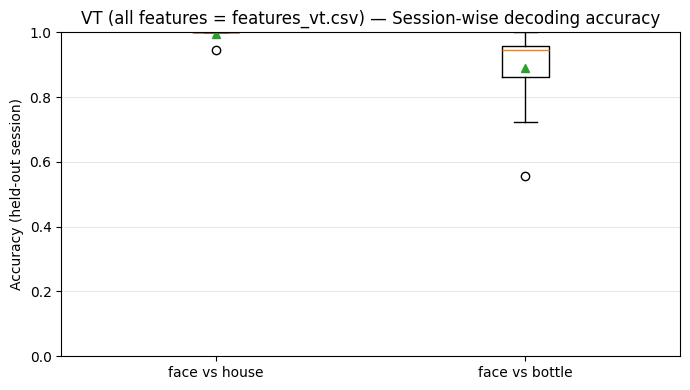

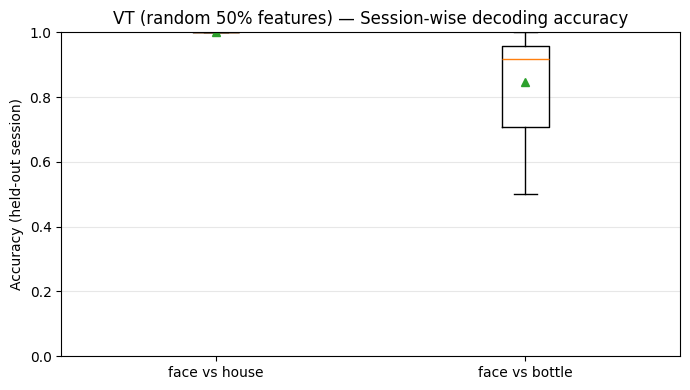

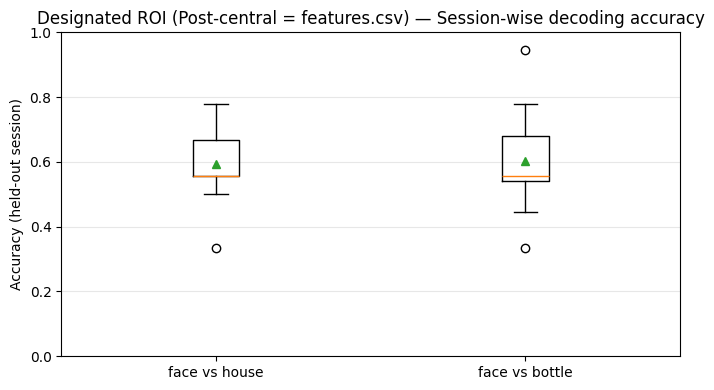

In [6]:
def boxplot_two_contrasts(acc_a, acc_b, title, save_path=None):
    plt.figure(figsize=(7, 4))
    plt.boxplot([acc_a, acc_b], tick_labels=["face vs house", "face vs bottle"], showmeans=True)
    plt.ylabel("Accuracy (held-out session)")
    plt.ylim(0.0, 1.0)
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


boxplot_two_contrasts(
    acc_fh_all, acc_fb_all,
    title="VT (all features = features_vt.csv) — Session-wise decoding accuracy",
    save_path=os.path.join(DATA_DIR, "fig_vt_all_boxplots.png")
)

boxplot_two_contrasts(
    acc_fh_50, acc_fb_50,
    title="VT (random 50% features) — Session-wise decoding accuracy",
    save_path=os.path.join(DATA_DIR, "fig_vt_50_boxplots.png")
)

boxplot_two_contrasts(
    acc_fh_roi, acc_fb_roi,
    title="Designated ROI (Post-central = features.csv) — Session-wise decoding accuracy",
    save_path=os.path.join(DATA_DIR, "fig_roi_postcentral_boxplots.png")
)


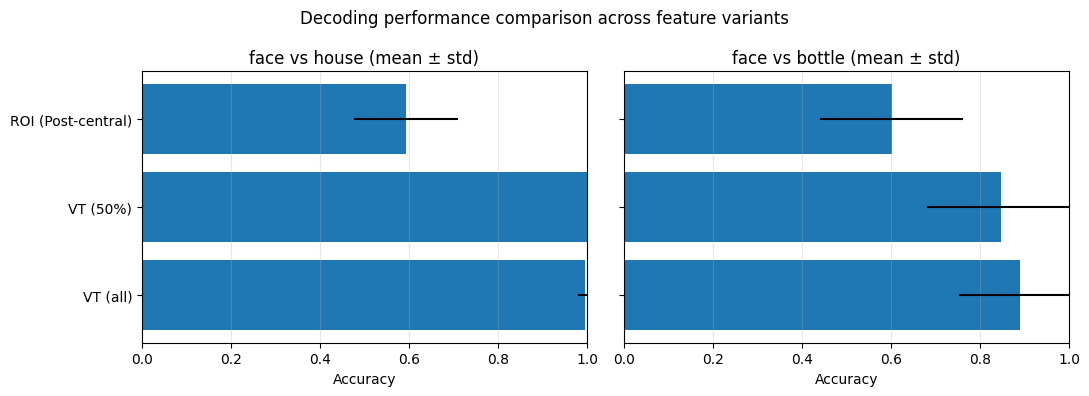

In [7]:
variants = ["VT (all)", "VT (50%)", "ROI (Post-central)"]

fh_means = [mean_std(acc_fh_all)[0], mean_std(acc_fh_50)[0], mean_std(acc_fh_roi)[0]]
fh_stds  = [mean_std(acc_fh_all)[1], mean_std(acc_fh_50)[1], mean_std(acc_fh_roi)[1]]

fb_means = [mean_std(acc_fb_all)[0], mean_std(acc_fb_50)[0], mean_std(acc_fb_roi)[0]]
fb_stds  = [mean_std(acc_fb_all)[1], mean_std(acc_fb_50)[1], mean_std(acc_fb_roi)[1]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ypos = np.arange(len(variants))

axes[0].barh(ypos, fh_means, xerr=fh_stds)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(variants)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Accuracy")
axes[0].set_title("face vs house (mean ± std)")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(ypos, fb_means, xerr=fb_stds)
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(variants)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Accuracy")
axes[1].set_title("face vs bottle (mean ± std)")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Decoding performance comparison across feature variants")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_variant_comparison_barplots.png"), dpi=200)
plt.show()


In [9]:
rows = []
def add_row(variant, contrast, accs):
    m, s = mean_std(accs)
    rows.append({
        "Variant": variant,
        "Contrast": contrast,
        "Mean accuracy": m,
        "Std accuracy": s,
        "Min": float(np.min(accs)),
        "Max": float(np.max(accs))
    })

add_row("VT (all)", "face vs house",  acc_fh_all)
add_row("VT (50%)", "face vs house",  acc_fh_50)
add_row("ROI",      "face vs house",  acc_fh_roi)

add_row("VT (all)", "face vs bottle", acc_fb_all)
add_row("VT (50%)", "face vs bottle", acc_fb_50)
add_row("ROI",      "face vs bottle", acc_fb_roi)

df_results = pd.DataFrame(rows)
df_results


,Variant,Contrast,Mean accuracy,Std accuracy,Min,Max
0,VT (all),face vs house,0.995370,0.016038,0.944444,1.000000
1,VT (50%),face vs house,1.000000,0.000000,1.000000,1.000000
2,ROI,face vs house,0.592593,0.116855,0.333333,0.777778
3,VT (all),face vs bottle,0.888889,0.136083,0.555556,1.000000
4,VT (50%),face vs bottle,0.847222,0.166034,0.500000,1.000000
5,ROI,face vs bottle,0.601852,0.160375,0.333333,0.944444


[fetch_haxby] Dataset found in /home/garima/nilearn_data/haxby2001
[fetch_atlas_harvard_oxford] Dataset found in /home/garima/nilearn_data/fsl


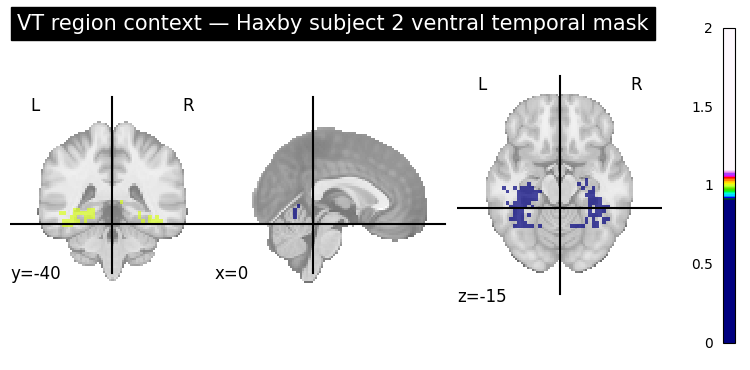

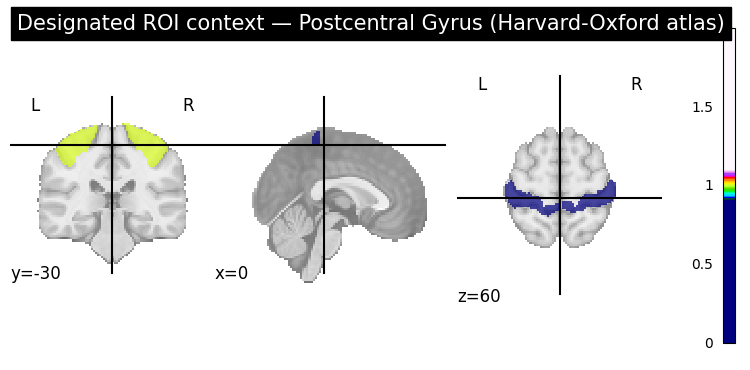

In [8]:
def plot_roi_and_vt_context(subj_id=2):
    """
    Nilearn visualizations to contextualize:
      (i) VT region and (ii) designated ROI (Post-central).
    This uses the Haxby dataset masks and Harvard-Oxford atlas for Postcentral.
    """
    try:
        from nilearn import datasets, plotting, image
    except Exception as e:
        raise ImportError(
            "Nilearn is required for atlas/mask visualization.\n"
            "Install: pip install nilearn\n"
            f"Original error: {e}"
        )

    # --- (i) VT context via Haxby VT mask ---
    haxby = datasets.fetch_haxby(subjects=(subj_id,), fetch_stimuli=False)
    vt_mask = haxby.mask_vt[0] if isinstance(haxby.mask_vt, (list, tuple)) else haxby.mask_vt

    plotting.plot_roi(
        vt_mask,
        title=f"VT region context — Haxby subject {subj_id} ventral temporal mask",
        display_mode="ortho",
        cut_coords=(0, -40, -15)
    )

    # --- (ii) Designated ROI context via Harvard-Oxford atlas (Postcentral) ---
    ho = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
    atlas_img = ho.maps
    atlas_labels = ho.labels

    post_idxs = [i for i, lab in enumerate(atlas_labels) if isinstance(lab, str) and "Postcentral" in lab]
    if not post_idxs:
        print("No 'Postcentral' label found in Harvard-Oxford labels.")
        print("Available labels sample:", atlas_labels[:30])
        return

    post_idx = post_idxs[0]
    post_name = atlas_labels[post_idx]
    post_mask = image.math_img(f"img == {post_idx}", img=atlas_img)

    plotting.plot_roi(
        post_mask,
        title=f"Designated ROI context — {post_name} (Harvard-Oxford atlas)",
        display_mode="ortho",
        cut_coords=(0, -30, 60)
    )

    plotting.show()

plot_roi_and_vt_context(subj_id=2)

## Summary / Discussion (required)

**Protocol**
- Decoding uses **Leave-One-Group-Out** CV with **12 sessions/chunks** as the group.
- Standardization and model fitting are done **inside each training fold** via a `Pipeline` (prevents leakage).

**Results overview**
- **VT (all)** is strongest overall (expected for category decoding).
- **VT (50%)** is typically close to VT(all), suggesting redundancy/distributed signal across VT voxels.
- **Designated ROI (Post-central)** is weaker than VT, which is plausible because it is not a classic ventral-visual category-selective region.

**Contrast difficulty (face vs house vs face vs bottle)**
- If **face vs house > face vs bottle**, houses may be more consistently separable from faces in these features.
- If the result is **reversed (face vs bottle > face vs house)**, possible reasons include:
  1) higher face–house representational overlap in the chosen ROI/features,
  2) ROI specialization mismatch (Post-central may capture non-visual confounds like motor/attention),
  3) session/run variability affecting one contrast more than the other,
  4) random VT-50% voxel selection favoring one contrast by chance.

**Session variability**
- Wider boxplots indicate stronger session-to-session variability (drift/noise).
- Narrower boxplots indicate more stable decoding across sessions.

**Brain visualizations (required)**
- The notebook includes (i) a VT-context visualization and (ii) a Post-central ROI-context visualization to support interpretation.